In [1]:
# ## 1. Setup

# %%
import os
import io
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 11, "axes.labelsize": 10})

# DATA_DIR  = r"C:\Users\andyz\Downloads\battery_dataset3\battery_dataset3\data"
# LABEL_DIR = r"C:\Users\andyz\Downloads\battery_dataset3\battery_dataset3\label" #commented out because using .pkl summary files now

COL_NAMES = [
    "avg_cell_voltage_V",
    "current_A",
    "soc_pct",
    "max_cell_voltage_V",
    "min_cell_voltage_V",
    "max_temp_C",
    "min_temp_C",
    "time_s",
]
N_SIGNAL_COLS = 7


In [ ]:

# # ## 2. Load Labels

# # %%
# df_labels = pd.read_csv(os.path.join(LABEL_DIR, "label.csv"))
# df_labels = df_labels.loc[:, ~df_labels.columns.str.startswith("Unnamed")]
# df_labels.columns = df_labels.columns.str.strip().str.lower()
# df_labels["car"]   = pd.to_numeric(df_labels["car"],   errors="coerce")
# df_labels["label"] = pd.to_numeric(df_labels["label"], errors="coerce")
# label_lookup = df_labels.set_index("car")["label"].to_dict()

# print(f"Degraded cars: {(df_labels['label'] == 0).sum()}  (used for RUL)")


In [4]:

# ## 2. Load From Cache


CACHE_MODE = "fast"     # change to "medium" to rebuild features

from pathlib import Path

SAVE_DIR        = Path(os.path.dirname(os.path.abspath("__file__")))
RAW_CACHE       = SAVE_DIR / "raw_loaded.pkl"
PROCESSED_CACHE = SAVE_DIR / "processed_features.pkl"

print(f"Cache mode: {CACHE_MODE!r}")

# %% [markdown]
# ### Cell A — Fast load (processed features)
# Runs only when `CACHE_MODE == "fast"`. Skips rebuilding derived features

# %%
if CACHE_MODE == "fast":
    if not PROCESSED_CACHE.exists():
        raise FileNotFoundError(
            f"No processed cache at {PROCESSED_CACHE}.\n"
            f"Either pull it from GitHub, or switch CACHE_MODE to 'medium'."
        )
    with open(PROCESSED_CACHE, "rb") as f:
        cache = pickle.load(f)

    df_meta       = cache["df_meta"]
    df_feats      = cache["df_feats"]
    df_feats_norm = cache["df_feats_norm"]
    df_rolling    = cache["df_rolling"]
    df_feats_all  = cache["df_feats_all"]
    label_lookup  = cache["label_lookup"]
    FEATURE_COLS  = cache["FEATURE_COLS"]
    COL_NAMES     = cache["COL_NAMES"]
    N_SIGNAL_COLS = cache["N_SIGNAL_COLS"]
    WINDOWS       = cache["WINDOWS"]
    MILEAGE_CAP   = cache["MILEAGE_CAP"]


    degraded_mask = (df_meta["label"] == 0).values

    print(f" Fast load from {PROCESSED_CACHE.name}")
    print(f"   Segments : {len(df_meta):,}")
    print(f"   Features : {len(FEATURE_COLS)}")
    print(f"   Cars     : {df_meta['car'].nunique()}")
    print(f"   SKIP Sections 3–9 — all features are pre-built.")
else:
    print(f"  Cell A skipped  (CACHE_MODE = {CACHE_MODE!r})")

# ### Cell B — Medium load (raw features, rebuild derived)
# Runs only when `CACHE_MODE == "medium"`. Loads `df_meta` and `df_feats`

# %%
if CACHE_MODE == "medium":
    if not RAW_CACHE.exists():
        raise FileNotFoundError(
            f"No raw cache at {RAW_CACHE}.\n"
            f"Either pull it from GitHub, or run the raw loading section from scratch."
        )
    with open(RAW_CACHE, "rb") as f:
        cache = pickle.load(f)

    meta_rows = cache["meta_rows"]
    feat_rows = cache["feat_rows"]
    df_meta   = cache["df_meta"]
    df_feats  = cache["df_feats"]

    # Try to get label_lookup from cache first (preferred, no paths needed)
    if "label_lookup" in cache:
        label_lookup = cache["label_lookup"]
        print("  Label lookup loaded from cache")
    else:
        # Fallback — rebuild from df_meta (works as long as 'label' column is in df_meta)
        if "label" in df_meta.columns:
            label_lookup = df_meta.set_index("car")["label"].to_dict()
            print("  Label lookup rebuilt from df_meta")
        else:
            raise RuntimeError(
                "label_lookup not in cache and df_meta has no 'label' column. "
                "You'll need to rerun the raw loader with access to label.csv."
            )

    print(f" Medium load from {RAW_CACHE.name}")
    print(f"   Segments : {len(df_meta):,}")
    print(f"   Features : {df_feats.shape[1]} (raw stats only)")
    print(f"   NEXT: run Sections 5–9 to rebuild derived features.")
else:
    print(f"  Cell B skipped  (CACHE_MODE = {CACHE_MODE!r})")

Cache mode: 'fast'
 Fast load from processed_features.pkl
   Segments : 172,390
   Features : 93
   Cars     : 48
   SKIP Sections 3–9 — all features are pre-built.
  Cell B skipped  (CACHE_MODE = 'fast')


In [ ]:

# # ## 3. Load Segments and Extract Per-Segment Features

# # %%
# def load_pkl(path: str):
#     with open(path, "rb") as f:
#         raw = f.read()
#     stream = io.BytesIO(raw)
#     objects = []
#     while True:
#         try:
#             objects.append(pickle.load(stream))
#         except EOFError:
#             break
#         except Exception:
#             return None
#     if len(objects) < 4:
#         return None
#     payload = objects[3]
#     if not (isinstance(payload, tuple) and len(payload) == 2):
#         return None
#     return payload[0], dict(payload[1])


# def extract_features(arr: np.ndarray) -> dict:
#     feats     = {}
#     time_norm = np.linspace(0, 1, arr.shape[0])
#     for i in range(N_SIGNAL_COLS):
#         col  = arr[:, i]
#         name = COL_NAMES[i]
#         feats[f"{name}__mean"]  = col.mean()
#         feats[f"{name}__std"]   = col.std()
#         feats[f"{name}__min"]   = col.min()
#         feats[f"{name}__max"]   = col.max()
#         feats[f"{name}__range"] = col.max() - col.min()
#         feats[f"{name}__slope"] = float(np.polyfit(time_norm, col, 1)[0])
#     return feats


# pkl_files = sorted(
#     [f for f in os.listdir(DATA_DIR) if f.endswith(".pkl")],
#     key=lambda x: int(x.replace(".pkl", "")) if x.replace(".pkl", "").isdigit() else 0,
# )
# print(f"PKL files: {len(pkl_files):,}")

# meta_rows, feat_rows, failed = [], [], 0
# for fname in pkl_files:
#     result = load_pkl(os.path.join(DATA_DIR, fname))
#     if result is None:
#         failed += 1; continue
#     arr, meta = result
#     file_idx  = int(fname.replace(".pkl", "")) if fname.replace(".pkl", "").isdigit() else fname
#     meta_rows.append({
#         "file_idx":       file_idx,
#         "car":            meta.get("car"),
#         "charge_segment": meta.get("charge_segment"),
#         "mileage":        meta.get("mileage"),
#         "capacity":       meta.get("capacity"),
#     })
#     feat_rows.append(extract_features(arr))

# print(f"Loaded: {len(meta_rows):,}   Failed: {failed}")


In [ ]:


# # ## 4. Build Master DataFrame & Remove Outliers

# # %%
# df_meta  = pd.DataFrame(meta_rows)
# df_feats = pd.DataFrame(feat_rows)

# for col in ["car", "mileage", "charge_segment", "capacity"]:
#     df_meta[col] = pd.to_numeric(df_meta[col], errors="coerce")

# df_meta = df_meta.merge(df_labels[["car", "label"]], on="car", how="left")

# sort_idx = df_meta.sort_values(["car", "mileage"]).index
# df_meta  = df_meta.loc[sort_idx].reset_index(drop=True)
# df_feats = df_feats.loc[sort_idx].reset_index(drop=True)

# MILEAGE_CAP  = 300_000
# car_max_mile = df_meta.groupby("car")["mileage"].max()
# keep_mask    = df_meta["car"].isin(car_max_mile[car_max_mile <= MILEAGE_CAP].index)

# df_meta  = df_meta[keep_mask].reset_index(drop=True)
# df_feats = df_feats[keep_mask].reset_index(drop=True)

# print(f"After cap: {df_meta['car'].nunique()} cars, {len(df_meta):,} segments")


In [ ]:

# ## 5. Build RUL Target

# %%
car_max_mile   = df_meta.groupby("car")["mileage"].transform("max")
df_meta["RUL"] = (car_max_mile - df_meta["mileage"]).clip(lower=0)
degraded_mask  = (df_meta["label"] == 0).values

print("RUL stats (degraded cars only):")
print(df_meta.loc[degraded_mask, "RUL"].describe().to_string())


RUL stats (degraded cars only):
count    73339.000000
mean     27282.752088
std      22299.162029
min          0.000000
25%       8145.984000
50%      21091.488000
75%      43871.520000
max      83567.616000


In [ ]:

# ## 6. Per-Car Normalisation (original stat features)

# %%
df_feats_norm = df_feats.copy()
car_ids       = df_meta["car"].values

for car_id in df_meta["car"].unique():
    cm = car_ids == car_id
    df_feats_norm.loc[cm] = df_feats.loc[cm] - df_feats.loc[cm].mean()

print("Per-car normalisation applied to the 42 stat features.")


Per-car normalisation applied to the 42 stat features.


In [ ]:

# ## 7. Rolling-Window Features
#
# For each car, sort segments chronologically, then compute rolling-window
# statistics on the mean signals over the last N segments.

WINDOWS = [5, 100]   # short-term (~5 charges) and long-term (~100 charges, smooths seasonal noise)

# Make sure rows are sorted
df_meta       = df_meta.sort_values(["car", "mileage"]).reset_index(drop=True)
df_feats      = df_feats.loc[df_meta.index].reset_index(drop=True)
df_feats_norm = df_feats_norm.loc[df_meta.index].reset_index(drop=True)

def rolling_slope(series: np.ndarray) -> float:
    """Linear slope of `series` against evenly spaced x — last value - first value trend."""
    n = len(series)
    if n < 2 or np.all(np.isnan(series)):
        return 0.0
    x = np.arange(n, dtype=np.float64)
    s = np.asarray(series, dtype=np.float64)
    if np.any(np.isnan(s)):
        mask = ~np.isnan(s)
        if mask.sum() < 2: return 0.0
        x, s = x[mask], s[mask]
    return float(np.polyfit(x, s, 1)[0])


rolling_frames = []

base_cols = [
    "max_temp_C__mean",
    "min_temp_C__mean",
    "max_temp_C__max",

    "current_A__mean",
    "current_A__min",  


    "avg_cell_voltage_V__range",   
    "avg_cell_voltage_V__slope",   
    "avg_cell_voltage_V__std",     
]
print(f"Rolling over {len(base_cols)} curated signals (not voltage mean):")
for c in base_cols:
    print(f"  • {c}")

# %%
for car_id in df_meta["car"].unique():
    cm   = df_meta["car"].values == car_id
    idx  = np.where(cm)[0]
    sub  = df_feats.loc[idx, base_cols]   # absolute means, chronological order
    out  = pd.DataFrame(index=idx)

    for N in WINDOWS:
        # rolling mean and std
        roll      = sub.rolling(window=N, min_periods=1)
        mean_df   = roll.mean().add_suffix(f"__rollmean_{N}")
        std_df    = roll.std().fillna(0).add_suffix(f"__rollstd_{N}")
        # rolling slope 
        slope_df  = roll.apply(rolling_slope, raw=True).add_suffix(f"__rollslope_{N}")
        out       = pd.concat([out, mean_df, std_df, slope_df], axis=1)

    rolling_frames.append(out)

df_rolling = pd.concat(rolling_frames).sort_index()
df_rolling = df_rolling.fillna(0)   

print(f"Rolling features built: {df_rolling.shape[1]} new features")
print(f"  Windows used: {WINDOWS}")
print(f"  First 5 rolling column names:")
for c in list(df_rolling.columns)[:5]:
    print(f"    {c}")


Rolling over 8 curated signals (not voltage mean):
  • max_temp_C__mean
  • min_temp_C__mean
  • max_temp_C__max
  • current_A__mean
  • current_A__min
  • avg_cell_voltage_V__range
  • avg_cell_voltage_V__slope
  • avg_cell_voltage_V__std
Rolling features built: 48 new features
  Windows used: [5, 100]
  First 5 rolling column names:
    max_temp_C__mean__rollmean_5
    min_temp_C__mean__rollmean_5
    max_temp_C__max__rollmean_5
    current_A__mean__rollmean_5
    current_A__min__rollmean_5


In [ ]:

# ## 8. Add lifetime position features

# %%
df_feats_norm["mileage_km"] = df_meta["mileage"].values.astype(np.float64)

ranks     = df_meta.groupby("car").cumcount().values
grp_sizes = df_meta.groupby("car")["car"].transform("count").values
df_feats_norm["charge_segment_rank"] = (ranks / np.maximum(grp_sizes - 1, 1)).astype(np.float64)

df_feats_norm["mileage_frac_of_car_max"] = (
    df_meta["mileage"] / df_meta.groupby("car")["mileage"].transform("max")
).clip(0, 1).values.astype(np.float64)


In [ ]:

# ## 9. Combine aall features

# %%
df_feats_all = pd.concat(
    [df_feats_norm.reset_index(drop=True),
     df_rolling.reset_index(drop=True)], axis=1
)
FEATURE_COLS = list(df_feats_all.columns)

print(f"Total features : {len(FEATURE_COLS)}")
print(f"  42 per-car normalised stat features")
print(f"  3 position features (mileage_km, charge_segment_rank, mileage_frac_of_car_max)")
# print(f"  {df_rolling.shape[1]} rolling-window features  ({WINDOWS} × 3 stats × 7 signals)") #replaced with below
print(f"  {df_rolling.shape[1]} rolling-window features  "
      f"({WINDOWS} × 3 stats × {len(base_cols)} curated signals)") #replaced above


Total features : 93
  42 per-car normalised stat features
  3 position features (mileage_km, charge_segment_rank, mileage_frac_of_car_max)
  48 rolling-window features  ([5, 100] × 3 stats × 8 curated signals)


In [5]:

# ## 10. Train / Val / Test Split — by Car ID

VAL_FRAC  = 0.15
TEST_FRAC = 0.15

def car_split(cars, val_frac, test_frac, rng):
    cars = list(cars); rng.shuffle(cars)
    n      = len(cars)
    n_test = max(1, int(np.ceil(n * test_frac)))
    n_val  = max(1, int(np.ceil(n * val_frac)))
    return cars[:n-n_test-n_val], cars[n-n_test-n_val:n-n_test], cars[n-n_test:]

rng = np.random.default_rng(seed=42)
degraded_cars = [c for c in df_meta["car"].unique() if label_lookup.get(c) == 0]
d_train, d_val, d_test = car_split(degraded_cars, VAL_FRAC, TEST_FRAC, rng)

cars_train, cars_val, cars_test = set(d_train), set(d_val), set(d_test)
assert cars_train.isdisjoint(cars_val) and \
       cars_train.isdisjoint(cars_test) and \
       cars_val.isdisjoint(cars_test), "Car overlap!"

train_mask = df_meta["car"].isin(cars_train).values & degraded_mask
val_mask   = df_meta["car"].isin(cars_val).values   & degraded_mask
test_mask  = df_meta["car"].isin(cars_test).values  & degraded_mask

print(f"{'Split':<8} {'Cars':>5} {'Segments':>10}")
print("─" * 28)
for name, mask in [("Train", train_mask), ("Val", val_mask), ("Test", test_mask)]:
    sub = df_meta[mask]
    print(f"{name:<8} {sub['car'].nunique():>5} {mask.sum():>10,}")


Split     Cars   Segments
────────────────────────────
Train       22     53,765
Val          5     16,760
Test         5      2,814


In [6]:

# ## 11. Build feature matrices and scale

# %%
X = df_feats_all.values.astype(np.float64)
y = df_meta["RUL"].values.astype(np.float64)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

car_groups_train = df_meta.loc[train_mask, "car"].values

scaler    = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}   Val: {X_val_s.shape}   Test: {X_test_s.shape}")


Train: (53765, 93)   Val: (16760, 93)   Test: (2814, 93)


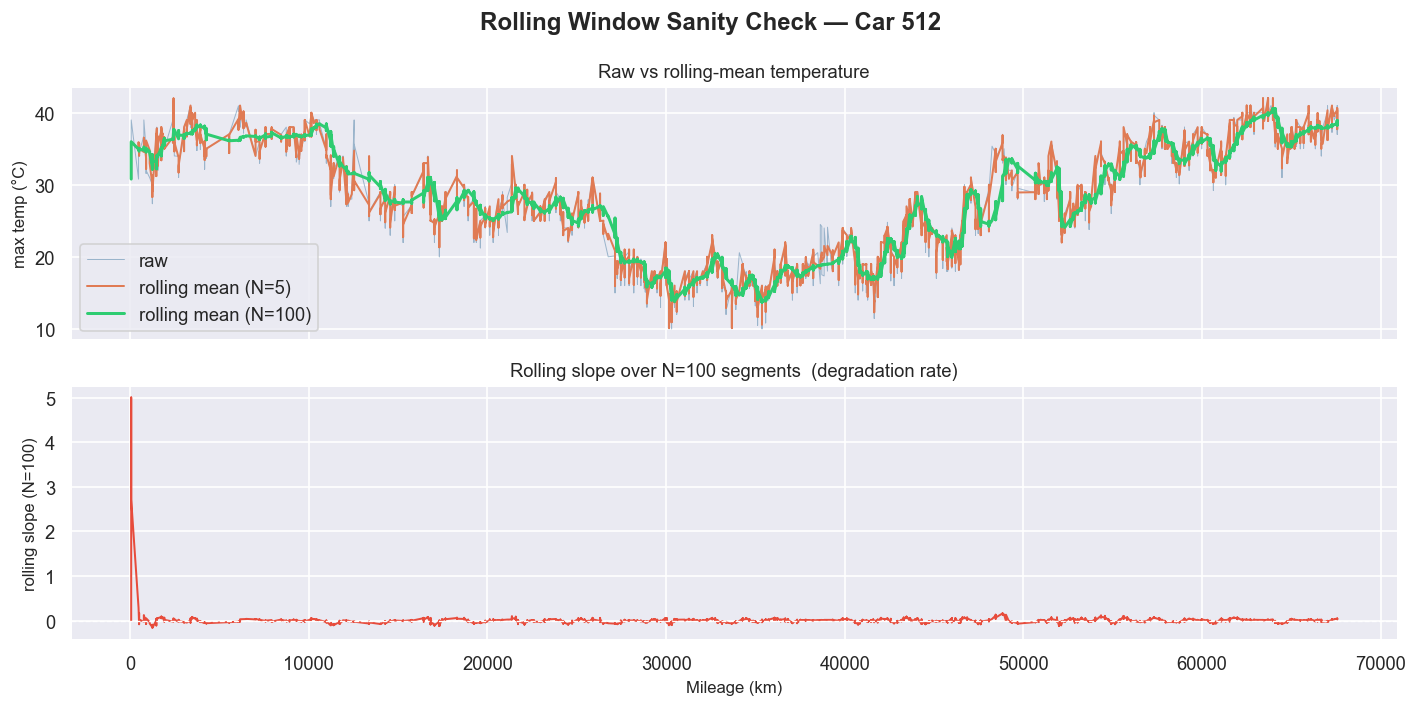

In [7]:

# ## 12. Check rolling eatures behave sensibly


sample_car   = list(cars_train)[0]
sample_mask  = (df_meta["car"] == sample_car).values

sample_df = df_meta.loc[sample_mask, ["mileage"]].copy()
# sample_df["raw_voltage_mean"]    = df_feats.loc[sample_mask, "avg_cell_voltage_V__mean"].values
# sample_df["roll5_voltage_mean"]  = df_rolling.loc[sample_mask, "avg_cell_voltage_V__mean__rollmean_5"].values
# sample_df["roll20_voltage_mean"] = df_rolling.loc[sample_mask, "avg_cell_voltage_V__mean__rollmean_20"].values
# sample_df["roll20_voltage_slope"] = df_rolling.loc[sample_mask, "avg_cell_voltage_V__mean__rollslope_20"].values #replaced with below
sample_df["raw_temp"]          = df_feats.loc[sample_mask, "max_temp_C__mean"].values
sample_df["roll5_temp"]        = df_rolling.loc[sample_mask, "max_temp_C__mean__rollmean_5"].values
sample_df["roll100_temp"]       = df_rolling.loc[sample_mask, "max_temp_C__mean__rollmean_100"].values
sample_df["roll100_temp_slope"] = df_rolling.loc[sample_mask, "max_temp_C__mean__rollslope_100"].values #replaced above
sample_df = sample_df.sort_values("mileage")

# %%
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle(f"Rolling Window Sanity Check — Car {sample_car}",
             fontweight="bold")

# axes[0].plot(sample_df["mileage"], sample_df["raw_voltage_mean"],
#              color="#4C7FA6", linewidth=0.6, alpha=0.5, label="raw")
# axes[0].plot(sample_df["mileage"], sample_df["roll5_voltage_mean"],
#              color="#E07B54", linewidth=1.2, label="rolling mean (N=5)")
# axes[0].plot(sample_df["mileage"], sample_df["roll20_voltage_mean"],
#              color="#2ECC71", linewidth=1.8, label="rolling mean (N=20)")
# axes[0].set_ylabel("avg cell voltage (V)")
# axes[0].legend()
# axes[0].set_title("Raw vs rolling-mean voltage")

# axes[1].plot(sample_df["mileage"], sample_df["roll20_voltage_slope"],
#              color="#E74C3C", linewidth=1.2) #replaced with below
axes[0].plot(sample_df["mileage"], sample_df["raw_temp"],
             color="#4C7FA6", linewidth=0.6, alpha=0.5, label="raw")
axes[0].plot(sample_df["mileage"], sample_df["roll5_temp"],
             color="#E07B54", linewidth=1.2, label="rolling mean (N=5)")
axes[0].plot(sample_df["mileage"], sample_df["roll100_temp"],
             color="#2ECC71", linewidth=1.8, label="rolling mean (N=100)")
axes[0].set_ylabel("max temp (°C)")
axes[0].legend()
axes[0].set_title("Raw vs rolling-mean temperature")

axes[1].plot(sample_df["mileage"], sample_df["roll100_temp_slope"],
             color="#E74C3C", linewidth=1.2) #replaced above
axes[1].axhline(0, color="white", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("rolling slope (N=100)")
axes[1].set_xlabel("Mileage (km)")
axes[1].set_title("Rolling slope over N=100 segments  (degradation rate)")
plt.tight_layout(); plt.show()


In [8]:

# ## 13. Train LinearRegression + Ridge Variants — Side by Side

# %%
MODELS = {
    "LinearRegression":    LinearRegression(),
    "Ridge (alpha=1)":     Ridge(alpha=1.0,    random_state=42),
    "Ridge (alpha=10)":    Ridge(alpha=10.0,   random_state=42),
    "Ridge (alpha=100)":   Ridge(alpha=100.0,  random_state=42),
    "Ridge (alpha=500)":   Ridge(alpha=500.0,  random_state=42),
    "Ridge (alpha=1000)":  Ridge(alpha=1000.0, random_state=42),
    "Lasso (alpha=10)":    Lasso(alpha=10.0,    random_state=42, max_iter=20000), #delete these if no Lasso
    "Lasso (alpha=100)":   Lasso(alpha=100.0,   random_state=42, max_iter=20000),
    "Lasso (alpha=1000)":  Lasso(alpha=1000.0,  random_state=42, max_iter=20000),
}

gkf = GroupKFold(n_splits=5)

all_results, all_preds = {}, {}

print(f"{'Model':<22} {'CV R²':>15} {'Train R²':>10} {'Val R²':>8} {'Test R²':>9} "
      f"{'Test MAE (km)':>15}")
print("─" * 85)

for name, model in MODELS.items():
    model_fit = model.__class__(**model.get_params())
    model_fit.fit(X_train_s, y_train)

    cv_scores = cross_val_score(
        model.__class__(**model.get_params()),
        X_train_s, y_train,
        cv=gkf, groups=car_groups_train, scoring="r2",
    )

    p_train = model_fit.predict(X_train_s)
    p_val   = model_fit.predict(X_val_s)
    p_test  = model_fit.predict(X_test_s)

    r2_tr, r2_va, r2_te = r2_score(y_train, p_train), r2_score(y_val, p_val), r2_score(y_test, p_test)
    mae_te = mean_absolute_error(y_test, p_test)

    print(f"{name:<22} {cv_scores.mean():>6.3f} +/- {cv_scores.std():.3f}  "
          f"{r2_tr:>9.3f} {r2_va:>8.3f} {r2_te:>9.3f} {mae_te:>14,.0f}")

    all_results[name] = {
        "model":  model_fit,
        "cv_r2":  cv_scores,
        "r2":     {"Train": r2_tr, "Val": r2_va, "Test": r2_te},
        "mae":    {"Train": mean_absolute_error(y_train, p_train),
                   "Val":   mean_absolute_error(y_val,   p_val),
                   "Test":  mae_te},
    }
    all_preds[name] = {"Train": p_train, "Val": p_val, "Test": p_test}


best_name  = max(all_results, key=lambda k: all_results[k]["cv_r2"].mean()) #uncomment if want best CV R^2
best_model = all_results[best_name]["model"]
best_preds = all_preds[best_name]
print(f"\n★ Best by CV R²: {best_name}")


Model                            CV R²   Train R²   Val R²   Test R²   Test MAE (km)
─────────────────────────────────────────────────────────────────────────────────────
LinearRegression        0.465 +/- 0.221      0.734    0.703    -1.448         18,607
Ridge (alpha=1)         0.479 +/- 0.214      0.734    0.701    -1.310         18,057
Ridge (alpha=10)        0.504 +/- 0.203      0.733    0.695    -0.736         15,424
Ridge (alpha=100)       0.525 +/- 0.195      0.725    0.680    -0.169         11,999
Ridge (alpha=500)       0.537 +/- 0.184      0.712    0.675    -0.024         11,410
Ridge (alpha=1000)      0.537 +/- 0.183      0.701    0.675    -0.022         11,620


/Users/noam/Downloads/Machine Learning Code/Machine-Learning-Final-Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.441e+09, tolerance: 2.195e+09
  model = cd_fast.enet_coordinate_descent(
/Users/noam/Downloads/Machine Learning Code/Machine-Learning-Final-Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.841e+09, tolerance: 2.037e+09
  model = cd_fast.enet_coordinate_descent(


Lasso (alpha=10)        0.510 +/- 0.204      0.728    0.697    -0.486         13,957
Lasso (alpha=100)       0.530 +/- 0.179      0.704    0.716     0.140         10,078
Lasso (alpha=1000)      0.545 +/- 0.157      0.587    0.641    -0.065         12,894

★ Best by CV R²: Lasso (alpha=1000)


In [9]:
# 13.25 Manually selecting best model

best_name = "Lasso (alpha=100)"
best_model = all_results[best_name]["model"]
best_preds = all_preds[best_name]
print(f"\n Best by CV R²: {best_name}")


 Best by CV R²: Lasso (alpha=100)


In [10]:
# # 13.5 Temporary for Lasso information

# # %%
# print("Feature sparsity by model:")
# print(f"{'Model':<22} {'Zeroed':>8} {'Kept':>6} {'% Zeroed':>10}")
# print("─" * 50)
# for name, res in all_results.items():
#     if hasattr(res["model"], "coef_"):
#         n_zero  = (res["model"].coef_ == 0).sum()
#         n_total = len(res["model"].coef_)
#         n_kept  = n_total - n_zero
#         print(f"{name:<22} {n_zero:>8} {n_kept:>6} {n_zero/n_total*100:>9.0f}%")

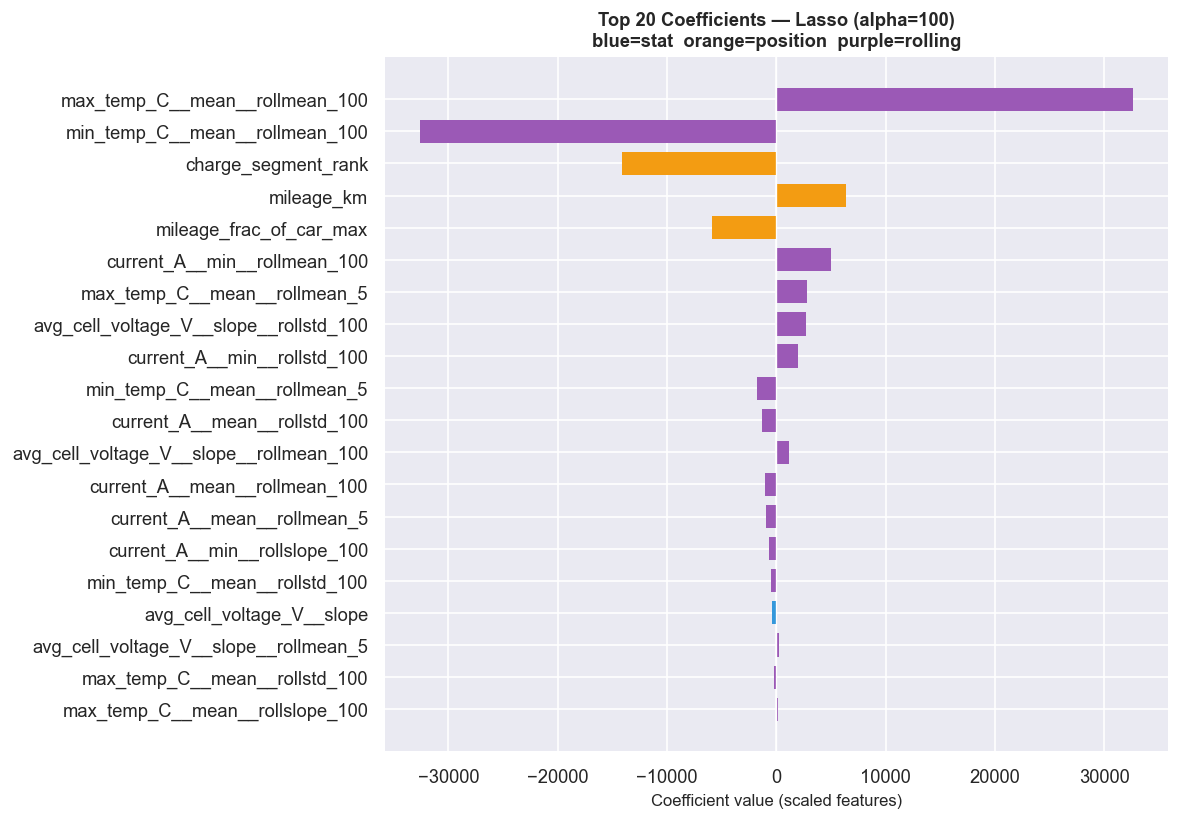


Top 20 coefficients (Lasso (alpha=100)):
                                feature          coef    group
         max_temp_C__mean__rollmean_100  32647.362148  rolling
         min_temp_C__mean__rollmean_100 -32606.797154  rolling
                    charge_segment_rank -14140.142989 position
                             mileage_km   6400.681978 position
                mileage_frac_of_car_max  -5849.363421 position
           current_A__min__rollmean_100   5030.432727  rolling
           max_temp_C__mean__rollmean_5   2799.073294  rolling
 avg_cell_voltage_V__slope__rollstd_100   2746.728258  rolling
            current_A__min__rollstd_100   1968.693375  rolling
           min_temp_C__mean__rollmean_5  -1729.103865  rolling
           current_A__mean__rollstd_100  -1336.403426  rolling
avg_cell_voltage_V__slope__rollmean_100   1153.638727  rolling
          current_A__mean__rollmean_100   -984.259810  rolling
            current_A__mean__rollmean_5   -907.198273  rolling
          cur

In [11]:

# ## 14. Coefficients — Best model (with feature group colouring)

# %%
def feat_group(name):
    if name in ("mileage_km", "charge_segment_rank", "mileage_frac_of_car_max"):
        return "position"
    if "__roll" in name:
        return "rolling"
    return "stat"

coef_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "coef": best_model.coef_})
    .assign(group=lambda d: d["feature"].map(feat_group),
            abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)
top20 = coef_df.head(20)

color_map = {"stat": "#3498DB", "position": "#F39C12", "rolling": "#9B59B6"}

fig, ax = plt.subplots(figsize=(10, 7))
colors = [color_map[g] for g in top20["group"][::-1]]
ax.barh(top20["feature"][::-1], top20["coef"][::-1],
        color=colors, edgecolor="none", height=0.72)
ax.axvline(0, color="white", linewidth=0.8)
ax.set_title(f"Top 20 Coefficients — {best_name}\n"
             f"blue=stat  orange=position  purple=rolling",
             fontweight="bold")
ax.set_xlabel("Coefficient value (scaled features)")

plt.tight_layout(); plt.show()

print(f"\nTop 20 coefficients ({best_name}):")
print(top20[["feature", "coef", "group"]].to_string(index=False))
print(f"\nIntercept: {best_model.intercept_:,.1f} km")

# How much each feature group contributes
print("\n── Coefficient magnitude by feature group ──")
group_summary = coef_df.groupby("group")["abs_coef"].agg(["sum", "mean", "count"])
group_summary["pct_of_total"] = (group_summary["sum"] / group_summary["sum"].sum() * 100).round(1)
print(group_summary.to_string())


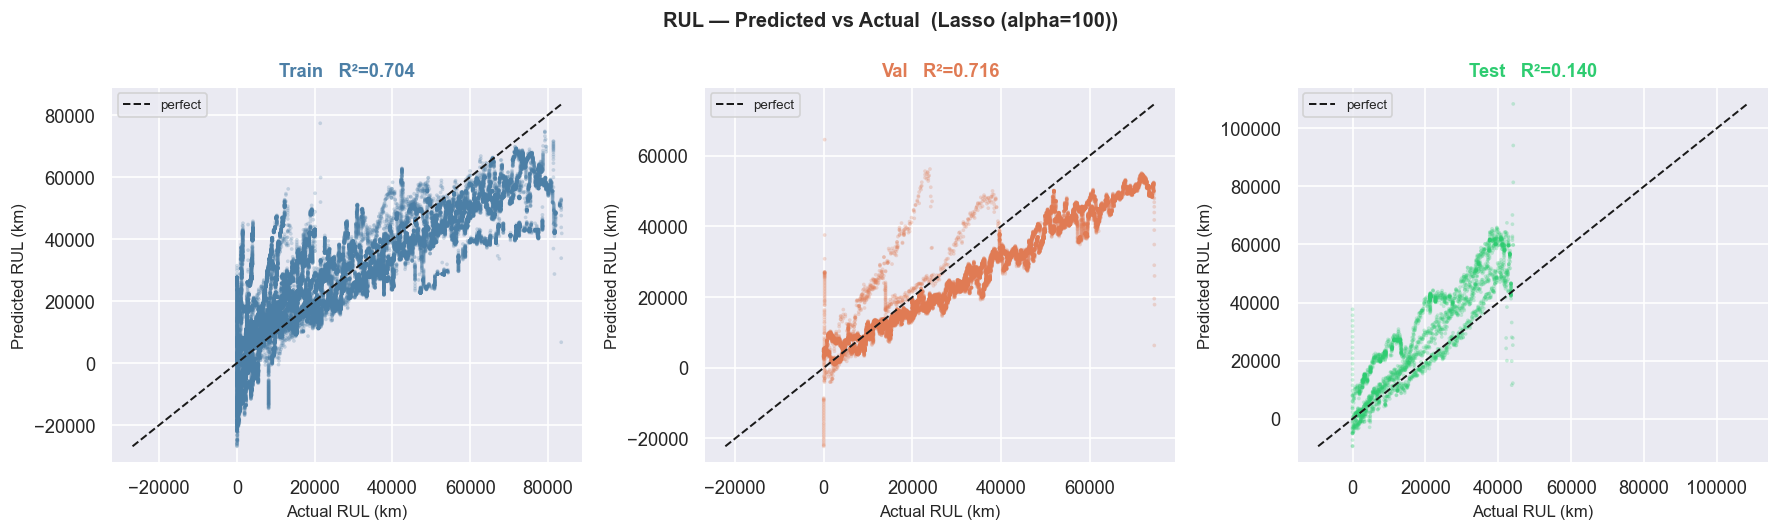

In [12]:

# ## 15. Predicted vs Actual — Best Model

# %%
split_colors = {"Train": "#4C7FA6", "Val": "#E07B54", "Test": "#2ECC71"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(f"RUL — Predicted vs Actual  ({best_name})",
             fontweight="bold", fontsize=12)

for ax, (sname, yt, yp) in zip(axes, [
    ("Train", y_train, best_preds["Train"]),
    ("Val",   y_val,   best_preds["Val"]),
    ("Test",  y_test,  best_preds["Test"]),
]):
    if len(yt) == 0:
        ax.axis("off"); ax.set_title(f"{sname} (no data)"); continue
    r2  = r2_score(yt, yp)
    col = split_colors[sname]
    ax.scatter(yt, yp, alpha=0.25, s=5, color=col, edgecolors="none")
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "k--", linewidth=1.2, label="perfect")
    ax.set_xlabel("Actual RUL (km)"); ax.set_ylabel("Predicted RUL (km)")
    ax.set_title(f"{sname}   R²={r2:.3f}", fontweight="bold", color=col)
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


Test performance by car:

   Car   N segs       R²     MAE (km)    Bias (km)
──────────────────────────────────────────────────
   505      468    0.710       5,926      +5,235
   509      554    0.790       3,301        +528
   517     1267   -0.463      15,259     +15,243
   525      497    0.441       8,019      +7,100
   547       28    0.000      15,685     +12,786
──────────────────────────────────────────────────
   ALL     2814    0.140      10,078


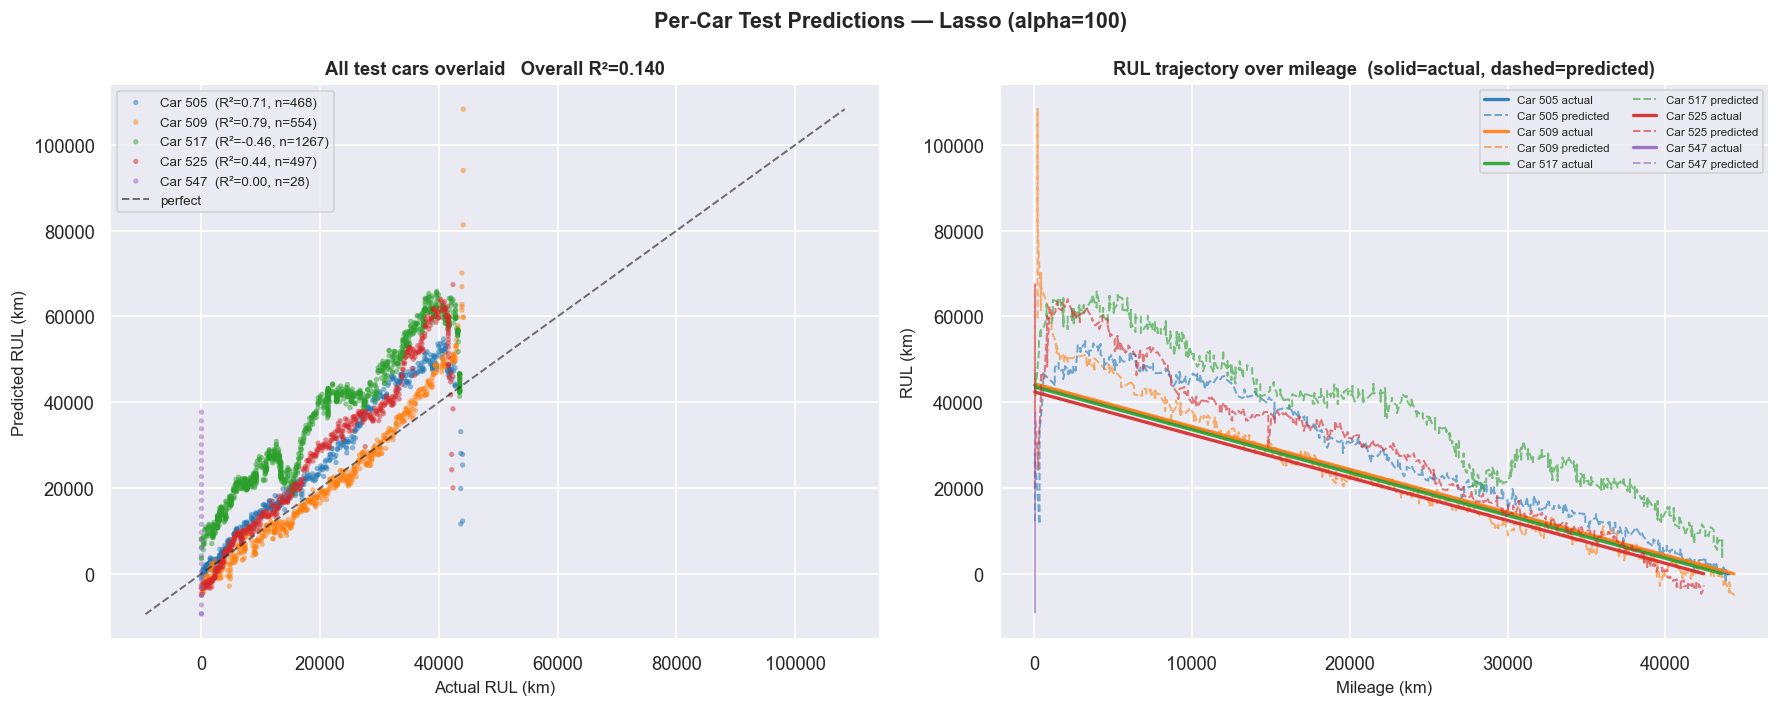


── Sensitivity check: R² if we exclude each car ──
  Without Car  505: R²=+0.018  (change: -0.122)
  Without Car  509: R²=+0.002  (change: -0.138)
  Without Car  517: R²=+0.623  (change: +0.483)  ← drags R² DOWN
  Without Car  525: R²=+0.074  (change: -0.066)
  Without Car  547: R²=+0.141  (change: +0.000)


In [13]:

# ## 15.5. Per-Car Predicted vs Actual — Test Set


# Get test predictions and rebuild a DataFrame with car IDs attached
test_preds = best_model.predict(X_test_s)
test_actual = y_test
test_cars   = df_meta.loc[test_mask, "car"].values

test_df = pd.DataFrame({
    "car":       test_cars,
    "actual":    test_actual,
    "predicted": test_preds,
})

# ── Per-car metrics ──────────────────────────────────────────────────────────
print("Test performance by car:\n")
print(f"{'Car':>6} {'N segs':>8} {'R²':>8} {'MAE (km)':>12} {'Bias (km)':>12}")
print("─" * 50)

per_car_results = []
for car_id, grp in test_df.groupby("car"):
    n_segs = len(grp)
    r2     = r2_score(grp["actual"], grp["predicted"]) if n_segs > 1 else np.nan
    mae    = mean_absolute_error(grp["actual"], grp["predicted"])
    bias   = (grp["predicted"] - grp["actual"]).mean()
    per_car_results.append({"car": int(car_id), "n_segs": n_segs,
                            "r2": r2, "mae": mae, "bias": bias})
    print(f"{int(car_id):>6} {n_segs:>8} {r2:>8.3f} {mae:>11,.0f} {bias:>+11,.0f}")

# Overall for comparison
overall_r2  = r2_score(test_actual, test_preds)
overall_mae = mean_absolute_error(test_actual, test_preds)
print("─" * 50)
print(f"{'ALL':>6} {len(test_df):>8} {overall_r2:>8.3f} {overall_mae:>11,.0f}")

# ── Two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Per-Car Test Predictions — {best_name}",
             fontweight="bold", fontsize=13)

# Use a distinct color for each car
test_car_ids = sorted(test_df["car"].unique())
palette = sns.color_palette("tab10", n_colors=len(test_car_ids))
car_colors = dict(zip(test_car_ids, palette))

# ── Left plot: all cars overlaid on one scatter ──
ax = axes[0]
for car_id in test_car_ids:
    grp = test_df[test_df["car"] == car_id]
    car_r2 = r2_score(grp["actual"], grp["predicted"]) if len(grp) > 1 else np.nan
    ax.scatter(grp["actual"], grp["predicted"],
               alpha=0.5, s=10, color=car_colors[car_id],
               label=f"Car {int(car_id)}  (R²={car_r2:.2f}, n={len(grp)})",
               edgecolors="none")

# Diagonal "perfect prediction" line
all_min = min(test_df["actual"].min(), test_df["predicted"].min())
all_max = max(test_df["actual"].max(), test_df["predicted"].max())
ax.plot([all_min, all_max], [all_min, all_max], "k--", linewidth=1.2,
        alpha=0.6, label="perfect")
ax.set_xlabel("Actual RUL (km)")
ax.set_ylabel("Predicted RUL (km)")
ax.set_title(f"All test cars overlaid   Overall R²={overall_r2:.3f}",
             fontweight="bold")
ax.legend(fontsize=8, loc="best")

# ── Right plot: predictions over mileage, per car ──
ax = axes[1]
test_df_with_mileage = test_df.copy()
test_df_with_mileage["mileage"] = df_meta.loc[test_mask, "mileage"].values

for car_id in test_car_ids:
    grp = test_df_with_mileage[test_df_with_mileage["car"] == car_id].sort_values("mileage")
    # Solid line = actual, dashed = predicted
    ax.plot(grp["mileage"], grp["actual"],
            color=car_colors[car_id], linewidth=2.0, alpha=0.9,
            label=f"Car {int(car_id)} actual")
    ax.plot(grp["mileage"], grp["predicted"],
            color=car_colors[car_id], linewidth=1.2, alpha=0.6,
            linestyle="--",
            label=f"Car {int(car_id)} predicted")

ax.set_xlabel("Mileage (km)")
ax.set_ylabel("RUL (km)")
ax.set_title("RUL trajectory over mileage  (solid=actual, dashed=predicted)",
             fontweight="bold")
ax.legend(fontsize=7, loc="best", ncol=2)

plt.tight_layout()
plt.show()

# ── Diagnose: which car is dragging R² down?
print("\n── Sensitivity check: R² if we exclude each car ──")
for car_id in test_car_ids:
    other = test_df[test_df["car"] != car_id]
    if len(other) > 1:
        r2_without = r2_score(other["actual"], other["predicted"])
        diff = r2_without - overall_r2
        marker = "  ← drags R² DOWN" if diff > 0.05 else ""
        print(f"  Without Car {int(car_id):>4}: R²={r2_without:+.3f}  "
              f"(change: {diff:+.3f}){marker}")

Validation performance by car:

   Car   N segs       R²     MAE (km)    Bias (km)
──────────────────────────────────────────────────
   506     9439    0.686       9,835      -9,125
   523     6416    0.746       7,946      -7,615
   526      261   -3.875      13,089     +13,081
   536      527    0.756       5,145      +3,218
   548      117 -44481.076      15,120      +6,027
──────────────────────────────────────────────────
   ALL    16760    0.716       9,052


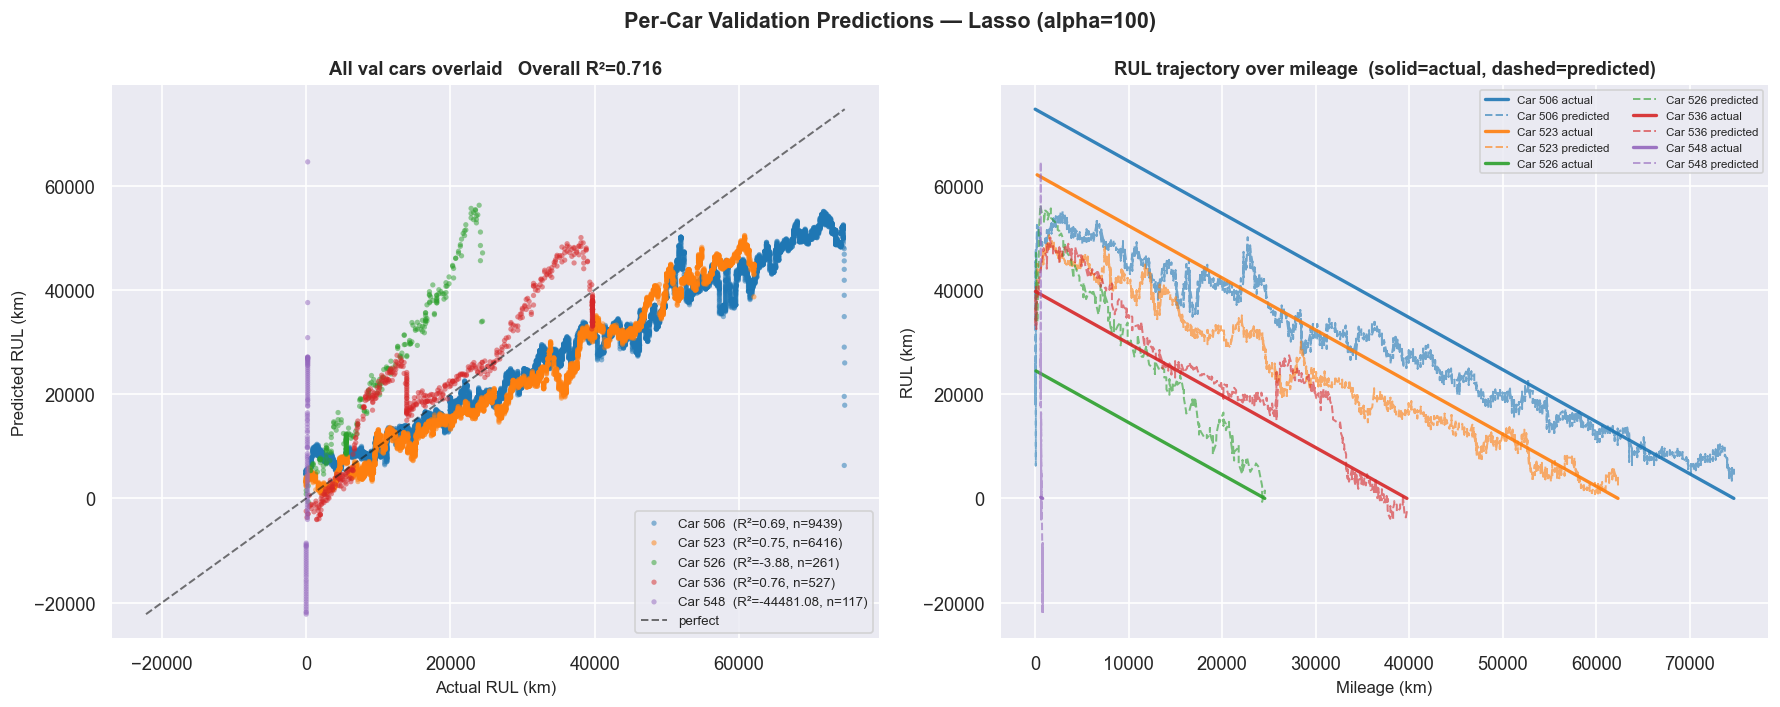


── Sensitivity check: R² if we exclude each car ──
  Without Car  506: R²=+0.736  (change: +0.019)
  Without Car  523: R²=+0.699  (change: -0.017)
  Without Car  526: R²=+0.719  (change: +0.002)
  Without Car  536: R²=+0.712  (change: -0.005)
  Without Car  548: R²=+0.716  (change: -0.000)


In [14]:

# ## 15.6. Per-Car Predicted vs Actual — Validation Set

# Get val predictions and rebuild a DataFrame with car IDs attached
val_preds  = best_model.predict(X_val_s)
val_actual = y_val
val_cars   = df_meta.loc[val_mask, "car"].values

val_df = pd.DataFrame({
    "car":       val_cars,
    "actual":    val_actual,
    "predicted": val_preds,
})

# ── Per-car metrics ──────────────────────────────────────────────────────────
print("Validation performance by car:\n")
print(f"{'Car':>6} {'N segs':>8} {'R²':>8} {'MAE (km)':>12} {'Bias (km)':>12}")
print("─" * 50)

for car_id, grp in val_df.groupby("car"):
    n_segs = len(grp)
    r2     = r2_score(grp["actual"], grp["predicted"]) if n_segs > 1 else np.nan
    mae    = mean_absolute_error(grp["actual"], grp["predicted"])
    bias   = (grp["predicted"] - grp["actual"]).mean()
    print(f"{int(car_id):>6} {n_segs:>8} {r2:>8.3f} {mae:>11,.0f} {bias:>+11,.0f}")

overall_r2_val  = r2_score(val_actual, val_preds)
overall_mae_val = mean_absolute_error(val_actual, val_preds)
print("─" * 50)
print(f"{'ALL':>6} {len(val_df):>8} {overall_r2_val:>8.3f} {overall_mae_val:>11,.0f}")

# ── Two side-by-side plots ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Per-Car Validation Predictions — {best_name}",
             fontweight="bold", fontsize=13)

val_car_ids = sorted(val_df["car"].unique())
palette = sns.color_palette("tab10", n_colors=len(val_car_ids))
val_car_colors = dict(zip(val_car_ids, palette))

# ── Left plot: all cars overlaid on one scatter ──
ax = axes[0]
for car_id in val_car_ids:
    grp = val_df[val_df["car"] == car_id]
    car_r2 = r2_score(grp["actual"], grp["predicted"]) if len(grp) > 1 else np.nan
    ax.scatter(grp["actual"], grp["predicted"],
               alpha=0.5, s=10, color=val_car_colors[car_id],
               label=f"Car {int(car_id)}  (R²={car_r2:.2f}, n={len(grp)})",
               edgecolors="none")

all_min = min(val_df["actual"].min(), val_df["predicted"].min())
all_max = max(val_df["actual"].max(), val_df["predicted"].max())
ax.plot([all_min, all_max], [all_min, all_max], "k--", linewidth=1.2,
        alpha=0.6, label="perfect")
ax.set_xlabel("Actual RUL (km)")
ax.set_ylabel("Predicted RUL (km)")
ax.set_title(f"All val cars overlaid   Overall R²={overall_r2_val:.3f}",
             fontweight="bold")
ax.legend(fontsize=8, loc="best")

# ── Right plot: predictions over mileage, per car ──
ax = axes[1]
val_df_with_mileage = val_df.copy()
val_df_with_mileage["mileage"] = df_meta.loc[val_mask, "mileage"].values

for car_id in val_car_ids:
    grp = val_df_with_mileage[val_df_with_mileage["car"] == car_id].sort_values("mileage")
    ax.plot(grp["mileage"], grp["actual"],
            color=val_car_colors[car_id], linewidth=2.0, alpha=0.9,
            label=f"Car {int(car_id)} actual")
    ax.plot(grp["mileage"], grp["predicted"],
            color=val_car_colors[car_id], linewidth=1.2, alpha=0.6,
            linestyle="--",
            label=f"Car {int(car_id)} predicted")

ax.set_xlabel("Mileage (km)")
ax.set_ylabel("RUL (km)")
ax.set_title("RUL trajectory over mileage  (solid=actual, dashed=predicted)",
             fontweight="bold")
ax.legend(fontsize=7, loc="best", ncol=2)

plt.tight_layout()
plt.show()

# ── Diagnose: which car is dragging val R² down (or up)? ────────────────────
print("\n── Sensitivity check: R² if we exclude each car ──")
for car_id in val_car_ids:
    other = val_df[val_df["car"] != car_id]
    if len(other) > 1:
        r2_without = r2_score(other["actual"], other["predicted"])
        diff = r2_without - overall_r2_val
        if diff > 0.05:
            marker = "  ← drags R² DOWN"
        elif diff < -0.05:
            marker = "  ← lifts R² UP (model relies on it)"
        else:
            marker = ""
        print(f"  Without Car {int(car_id):>4}: R²={r2_without:+.3f}  "
              f"(change: {diff:+.3f}){marker}")

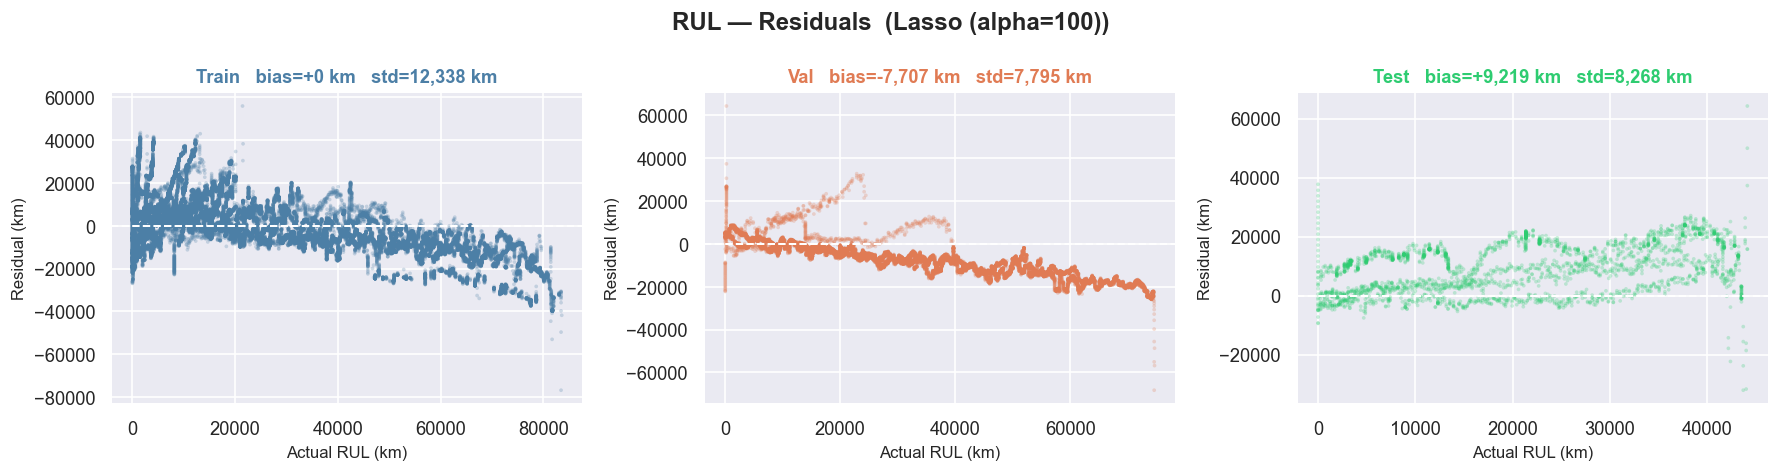

In [15]:

# ## 16. Residuals — Best Model

# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"RUL — Residuals  ({best_name})", fontweight="bold")

for ax, (sname, yt, yp) in zip(axes, [
    ("Train", y_train, best_preds["Train"]),
    ("Val",   y_val,   best_preds["Val"]),
    ("Test",  y_test,  best_preds["Test"]),
]):
    if len(yt) == 0: ax.axis("off"); continue
    res = yp - yt
    col = split_colors[sname]
    ax.scatter(yt, res, alpha=0.25, s=5, color=col, edgecolors="none")
    ax.axhline(0, color="white", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Actual RUL (km)"); ax.set_ylabel("Residual (km)")
    ax.set_title(f"{sname}   bias={res.mean():+,.0f} km   std={res.std():,.0f} km",
                 fontweight="bold", color=col)

plt.tight_layout(); plt.show()


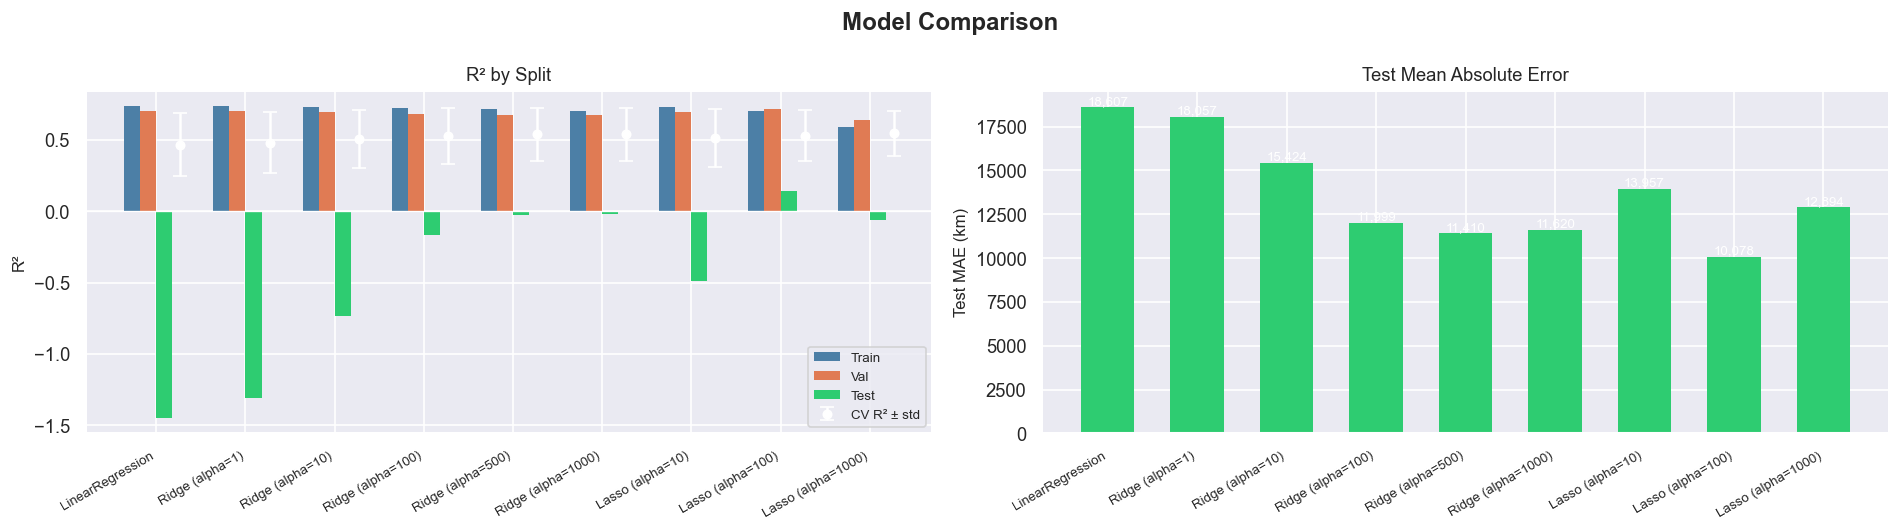

In [16]:

# ## 17. Model Comparison — side by side

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))  
fig.suptitle("Model Comparison", fontweight="bold")

model_names = list(all_results.keys())
metrics_r2  = {s: [all_results[m]["r2"][s] for m in model_names]
               for s in ["Train", "Val", "Test"]}
cv_means    = [all_results[m]["cv_r2"].mean() for m in model_names]
cv_stds     = [all_results[m]["cv_r2"].std()  for m in model_names]

ax = axes[0]
x  = np.arange(len(model_names))
w  = 0.18                                         
positions = [-1.5, -0.5, 0.5]
for (sname, vals), pos in zip(metrics_r2.items(), positions):
    ax.bar(x + pos * w, vals, w, label=sname, color=split_colors[sname], edgecolor="none")
ax.errorbar(x + 1.5 * w, cv_means, yerr=cv_stds, fmt="o", color="white",
            ecolor="white", capsize=4, markersize=5, label="CV R² ± std")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)   
ax.set_ylabel("R²"); ax.set_title("R² by Split")
ax.axhline(0, color="white", linewidth=0.8); ax.legend(fontsize=8)

ax = axes[1]
mae_vals = [all_results[m]["mae"]["Test"] for m in model_names]
ax.bar(x, mae_vals, color="#2ECC71", edgecolor="none", width=0.6)
for i, v in enumerate(mae_vals):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8, color="white")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Test MAE (km)"); ax.set_title("Test Mean Absolute Error")

plt.tight_layout(); plt.show()

In [17]:


# ## 18. Summary


print("=" * 70)
print("RUL RESULTS — Rolling Windows + Linear Models")
print("=" * 70)
print(f"\nFeatures: {X_train.shape[1]} total")
print(f"  42 per-car normalised stat features")
print(f"  3 lifetime position features")
print(f"  {df_rolling.shape[1]} rolling-window features  (windows = {WINDOWS})")
print(f"\nTraining on degraded cars only ({len(y_train):,} segments)\n")

print(f"{'Model':<22} {'CV R²':>15} {'Train R²':>10} {'Val R²':>8} {'Test R²':>9} {'Test MAE':>13}")
print("─" * 85)
for name, res in all_results.items():
    marker = " ★" if name == best_name else "  "
    print(f"{marker}{name:<20} "
          f"{res['cv_r2'].mean():>6.3f} +/- {res['cv_r2'].std():.3f}  "
          f"{res['r2']['Train']:>9.3f} {res['r2']['Val']:>8.3f} {res['r2']['Test']:>9.3f} "
          f"{res['mae']['Test']:>12,.0f}")

print(f"\nBaseline (always predict mean RUL): "
      f"MAE ≈ {np.mean(np.abs(y_test - y_train.mean())):,.0f} km")


RUL RESULTS — Rolling Windows + Linear Models

Features: 93 total
  42 per-car normalised stat features
  3 lifetime position features
  48 rolling-window features  (windows = [5, 100])

Training on degraded cars only (53,765 segments)

Model                            CV R²   Train R²   Val R²   Test R²      Test MAE
─────────────────────────────────────────────────────────────────────────────────────
  LinearRegression      0.465 +/- 0.221      0.734    0.703    -1.448       18,607
  Ridge (alpha=1)       0.479 +/- 0.214      0.734    0.701    -1.310       18,057
  Ridge (alpha=10)      0.504 +/- 0.203      0.733    0.695    -0.736       15,424
  Ridge (alpha=100)     0.525 +/- 0.195      0.725    0.680    -0.169       11,999
  Ridge (alpha=500)     0.537 +/- 0.184      0.712    0.675    -0.024       11,410
  Ridge (alpha=1000)    0.537 +/- 0.183      0.701    0.675    -0.022       11,620
  Lasso (alpha=10)      0.510 +/- 0.204      0.728    0.697    -0.486       13,957
 ★Lasso (alph

In [18]:

# ## 19. Save Processed Features for Reuse


# %%
import pickle
from pathlib import Path

# Folder containing this notebook/script — where we save the output
SAVE_DIR = Path(os.path.dirname(os.path.abspath("__file__")))
OUTPUT_PATH = SAVE_DIR / "processed_features.pkl"

payload = {
    "df_meta":       df_meta,

    "df_feats":      df_feats,       # raw 42 stat features (absolute values)
    "df_feats_norm": df_feats_norm,  # per-car normalised + position features
    "df_rolling":    df_rolling,     # rolling-window features
    "df_feats_all":  df_feats_all,   # combined matrix actually used for training

    "label_lookup":  label_lookup,
    "FEATURE_COLS":  FEATURE_COLS,
    "COL_NAMES":     COL_NAMES,
    "N_SIGNAL_COLS": N_SIGNAL_COLS,
    "WINDOWS":       WINDOWS,
    "MILEAGE_CAP":   MILEAGE_CAP,
}

with open(OUTPUT_PATH, "wb") as f:
    pickle.dump(payload, f)

size_mb = OUTPUT_PATH.stat().st_size / 1024 / 1024
print(f" Saved processed features to: {OUTPUT_PATH}")
print(f"   File size : {size_mb:.1f} MB")
print(f"   Contains  : {len(df_meta):,} segments × {len(FEATURE_COLS)} features")

 Saved processed features to: /Users/noam/Downloads/Machine Learning Code/Machine-Learning-Final-Project/processed_features.pkl
   File size : 310.4 MB
   Contains  : 172,390 segments × 93 features


In [ ]:
# %%
import pickle
from pathlib import Path

SAVE_DIR  = Path(os.path.dirname(os.path.abspath("__file__")))
RAW_CACHE = SAVE_DIR / "raw_loaded.pkl"

with open(RAW_CACHE, "wb") as f:
    pickle.dump({
        "meta_rows": meta_rows,
        "feat_rows": feat_rows,
        "df_meta":   df_meta,
        "df_feats":  df_feats,
        "label_lookup": label_lookup, #added to make cache work on different people's computers
    }, f)

size_mb = RAW_CACHE.stat().st_size / 1024 / 1024
print(f" Raw cache saved: {RAW_CACHE}")
print(f"   Size: {size_mb:.1f} MB  ({len(meta_rows):,} segments)")